Unemployment Analysis with Python

Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
%matplotlib inline

Load Dataset

In [2]:
df = pd.read_csv("Unemployment in India.csv")
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


Data Cleaning

Remove extra spaces from column names

In [3]:
df.columns = df.columns.str.strip()

Check columns

In [4]:
print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


Convert Date column into datetime

In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

Dataset info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   740 non-null    object        
 1   Date                                     740 non-null    datetime64[ns]
 2   Frequency                                740 non-null    object        
 3   Estimated Unemployment Rate (%)          740 non-null    float64       
 4   Estimated Employed                       740 non-null    float64       
 5   Estimated Labour Participation Rate (%)  740 non-null    float64       
 6   Area                                     740 non-null    object        
dtypes: datetime64[ns](1), float64(3), object(3)
memory usage: 42.1+ KB


Check Missing Values

In [7]:
print(df.isnull().sum())

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64


Remove missing values

In [8]:
df = df.dropna()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (740, 7)


Basic Statistics

In [9]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


Visualization

Overall Unemployment Rate Distribution

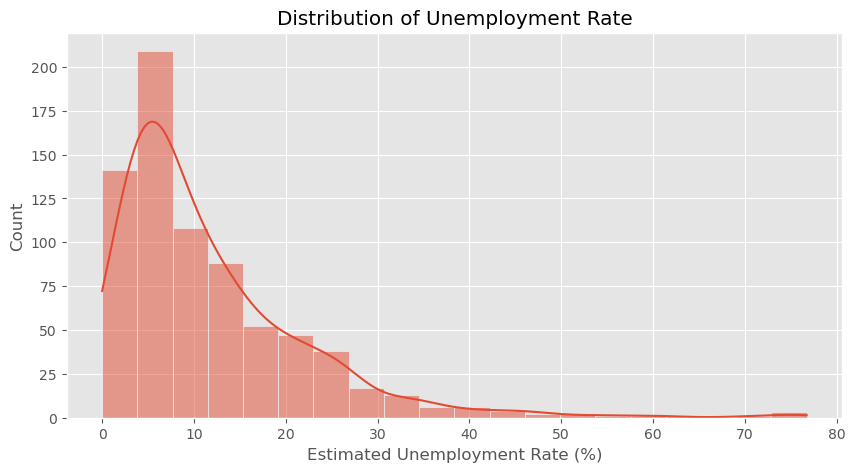

In [10]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Estimated Unemployment Rate (%)'],
    bins=20,
    kde=True
)

plt.title("Distribution of Unemployment Rate")
plt.show()

Average Unemployment by Area

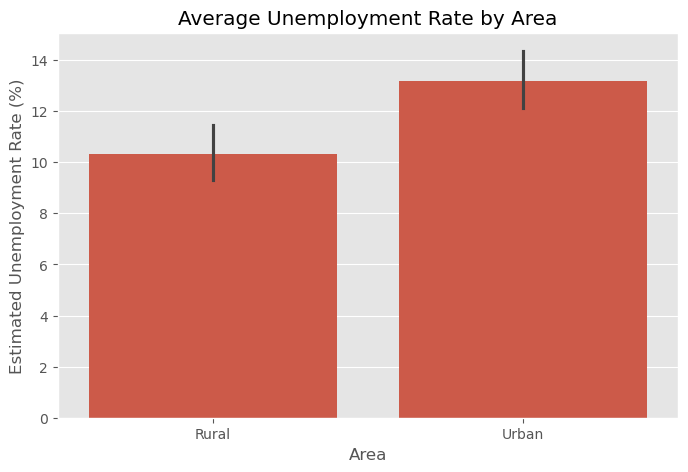

In [11]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Average Unemployment Rate by Area")
plt.show()

State-wise Unemployment Rate

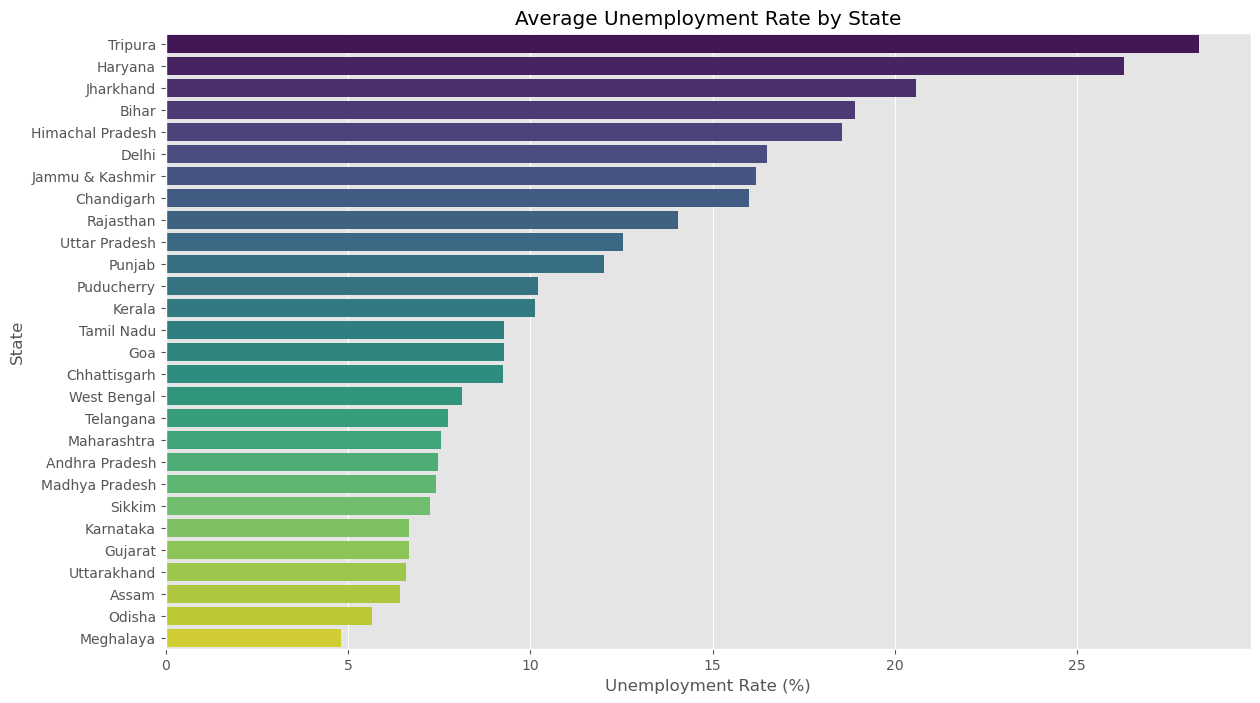

In [12]:
state_unemployment = df.groupby('Region')[
    'Estimated Unemployment Rate (%)'
].mean().sort_values(ascending=False)

plt.figure(figsize=(14,8))

sns.barplot(
    x=state_unemployment.values,
    y=state_unemployment.index,
    hue=state_unemployment.index,
    palette='viridis',
    legend=False
)

plt.title("Average Unemployment Rate by State")
plt.xlabel("Unemployment Rate (%)")
plt.ylabel("State")

plt.show()

Monthly Unemployment Trend

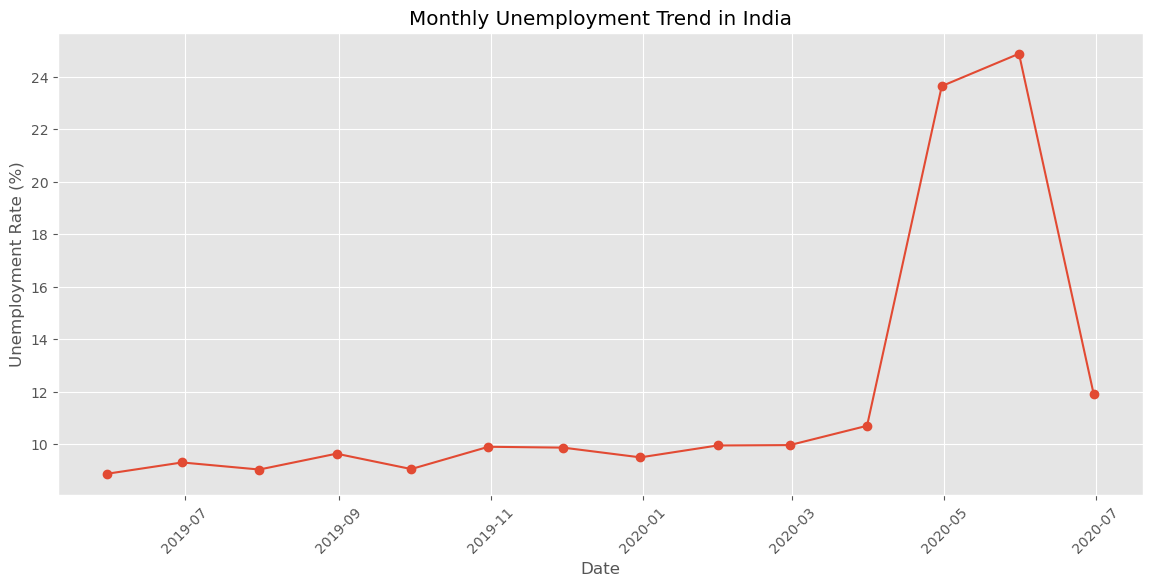

In [13]:
monthly_unemployment = df.groupby('Date')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(14,6))

plt.plot(
    monthly_unemployment.index,
    monthly_unemployment.values,
    marker='o'
)

plt.title("Monthly Unemployment Trend in India")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)

plt.show()

Covid-19 Impact Analysis

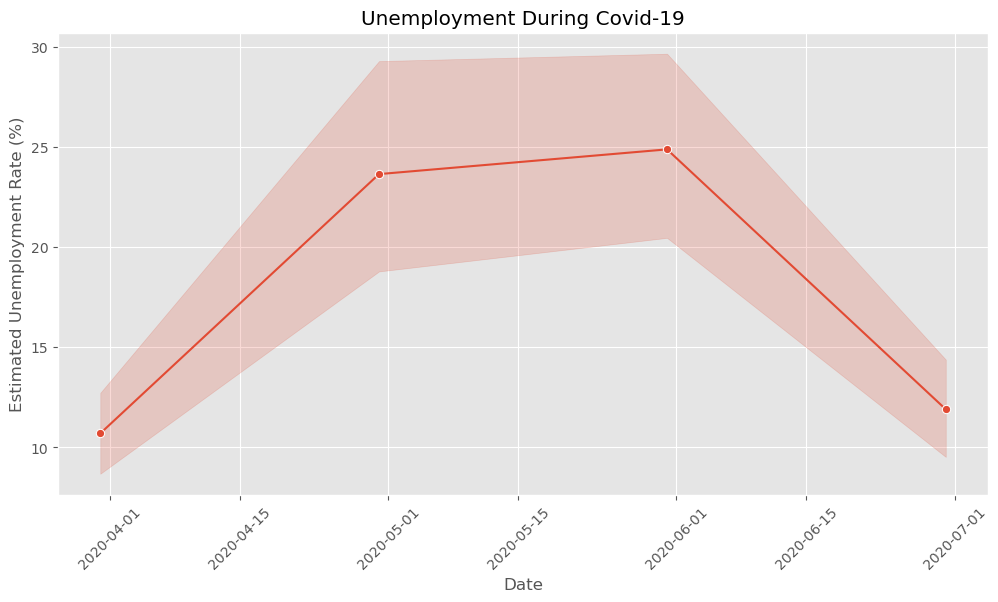

In [14]:
covid_period = df[
    (df['Date'] >= '2020-03-01') &
    (df['Date'] <= '2020-08-31')
]

plt.figure(figsize=(12,6))

sns.lineplot(
    x='Date',
    y='Estimated Unemployment Rate (%)',
    data=covid_period,
    marker='o'
)

plt.title("Unemployment During Covid-19")
plt.xticks(rotation=45)

plt.show()

Correlation Heatmap

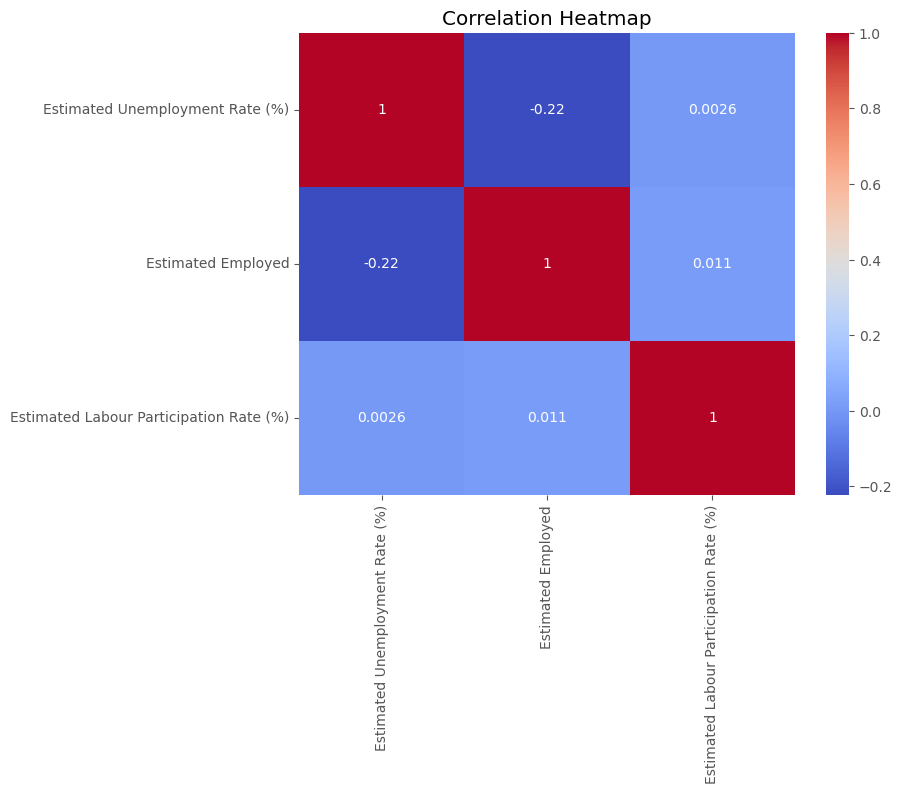

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[['Estimated Unemployment Rate (%)',
        'Estimated Employed',
        'Estimated Labour Participation Rate (%)']]
    .corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

Insights

1) Most unemployment rates were concentrated within a particular range, while a few extreme values indicate periods of unusually high unemployment across the country.
   
2) Urban and Rural areas exhibited different unemployment patterns, suggesting variations in job availability, economic activities, and workforce participation.

3) Unemployment rates varied significantly across states, reflecting regional differences in economic development and employment opportunities.

4) The unemployment rate showed noticeable month-to-month fluctuations, indicating changing labour market conditions over time.

5) A substantial rise in unemployment was observed during the Covid-19 period, highlighting the negative impact of lockdowns and economic disruptions on employment.

6) The correlation analysis revealed relationships among unemployment rate, employment levels, and labour participation rate, helping to better understand labour market dynamics.
   